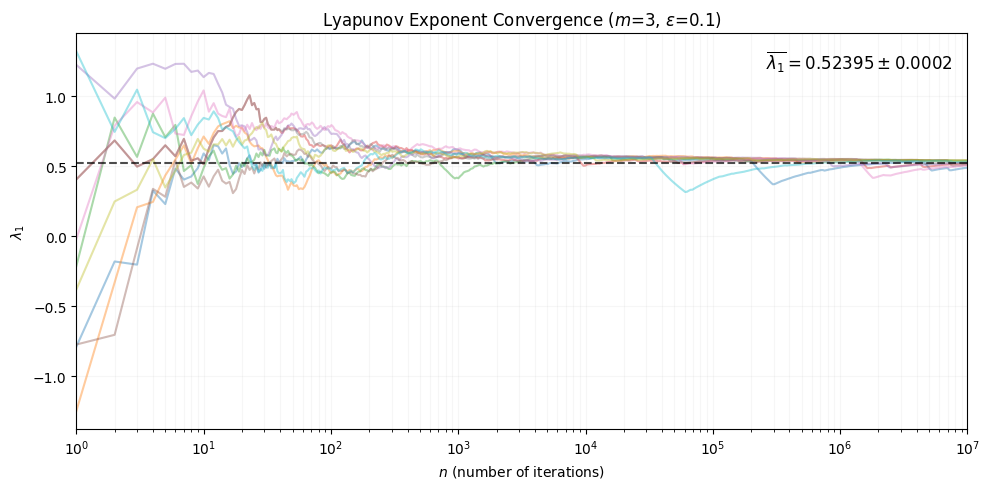

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

# Use the formatting helper for LaTeX labels
def format_coord(val):
    multiple = val / np.pi
    if np.isclose(multiple, 0.125): return r"$\pi/8$"
    if np.isclose(multiple, 0.25):  return r"$\pi/4$"
    if np.isclose(multiple, 0.5):   return r"$\pi/2$"
    if np.isclose(multiple, 0.75):  return r"$3\pi/4$"
    if np.isclose(multiple, 0.875): return r"$7\pi/8$"
    if np.isclose(multiple, 1.0):   return r"$\pi$"
    return f"{val:.2f}"

data = np.load("data/lyapunov_convergence_20260516_10000000iters.npz", allow_pickle=True)
m, epsilon, n_iters = data['metadata']
seeds = data['seeds']

plt.figure(figsize=(10, 5))
all_final_lambdas = []
all_final_errors = []

# 2. Iterate and plot history lines
for i in range(len(seeds)):
    # res is an object array: [n_history_arr, lam_history_arr, mu_scalar, sem_scalar]
    res = data[f"seed_{i}"]
    
    n_history = res[0]
    lam_history = res[1]
    
    # Extract scalar results for aggregate statistics
    all_final_lambdas.append(res[2]) 
    all_final_errors.append(res[3])

    # Plot the full sequence as a line
    plt.plot(n_history, lam_history, alpha=0.4, linewidth=1.5)

# 3. Calculate and display Grand Statistics
grand_mean = np.mean(all_final_lambdas)
max_error = np.max(all_final_errors)

label_text = fr"$\overline{{\lambda_1}} = {grand_mean:.5f} \pm {max_error:.4f}$"
plt.axhline(y=grand_mean, color='black', linestyle='--', alpha=0.7)
plt.plot([], [], ' ', label=label_text) # Ghost plot for legend text

# Formatting to match the desired academic style
plt.xscale('log')
# Explicitly start the viewport window at 1 to view the transient oscillations
plt.xlim(1, n_iters)
plt.gca().xaxis.set_major_locator(LogLocator(base=10.0))

plt.xlabel(r'$n$ (number of iterations)')
plt.ylabel(r'$\lambda_1$')
plt.title(fr'Lyapunov Exponent Convergence ($m$={int(m)}, $\epsilon$={epsilon})')
plt.legend(loc='upper right', frameon=False, fontsize='large')
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.tight_layout()
plt.show()